In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
building_info = pd.read_csv('./building_info.csv')
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')

In [27]:
print('<building_info dataset columns>')
print(building_info.columns, '\n')

print('<train_df dataset columns>')
print(train_df.columns, '\n')

print('<test_df dataset columns>')
print(test_df.columns, '\n')

<building_info dataset columns>
Index(['건물번호', '건물유형', '연면적(m2)', '냉방면적(m2)', '태양광용량(kW)', 'ESS저장용량(kWh)',
       'PCS용량(kW)'],
      dtype='object') 

<train_df dataset columns>
Index(['num_date_time', '건물번호', '일시', '기온(C)', '강수량(mm)', '풍속(m/s)', '습도(%)',
       '일조(hr)', '일사(MJ/m2)', '전력소비량(kWh)'],
      dtype='object') 

<test_df dataset columns>
Index(['num_date_time', '건물번호', '일시', '기온(C)', '강수량(mm)', '풍속(m/s)', '습도(%)'], dtype='object') 



In [28]:
building_info.head(3)

,건물번호,건물유형,연면적(m2),냉방면적(m2),태양광용량(kW),ESS저장용량(kWh),PCS용량(kW)
0,1,건물기타,110634.00,39570.0,-,-,-
1,2,건물기타,122233.47,99000.0,-,-,-
2,3,건물기타,171243.00,113950.0,40,-,-


In [29]:
building_info = building_info.rename(columns={
    '건물번호': 'building_number',
    '건물유형': 'building_type',
    '연면적(m2)': 'total_area',
    '냉방면적(m2)': 'cooling_area',
    '태양광용량(kW)': 'solar_power_capacity',
    'ESS저장용량(kWh)': 'ess_capacity',
    'PCS용량(kW)': 'pcs_capacity'
})

In [30]:
building_info.isna().sum()

building_number         0
building_type           0
total_area              0
cooling_area            0
solar_power_capacity    0
ess_capacity            0
pcs_capacity            0
dtype: int64

In [31]:
building_info['building_type'].unique()

array(['건물기타', '공공', '대학교', '데이터센터', '백화점및아울렛', '병원', '상용', '아파트', '연구소',
       '지식산업센터', '할인마트', '호텔및리조트'], dtype=object)

In [32]:
translation_dict = {
    '건물기타': 'Other Buildings',
    '공공': 'Public',
    '대학교': 'University',
    '데이터센터': 'Data Center',
    '백화점및아울렛': 'Department Store and Outlet',
    '병원': 'Hospital',
    '상용': 'Commercial',
    '아파트': 'Apartment',
    '연구소': 'Research Institute',
    '지식산업센터': 'Knowledge Industry Center',
    '할인마트': 'Discount Mart',
    '호텔및리조트': 'Hotel and Resort'
}

building_info['building_type'] = building_info['building_type'].replace(translation_dict)

In [33]:
building_info.head(3)

,building_number,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity
0,1,Other Buildings,110634.00,39570.0,-,-,-
1,2,Other Buildings,122233.47,99000.0,-,-,-
2,3,Other Buildings,171243.00,113950.0,40,-,-


In [34]:
print('solar_power_capacity: ', building_info['solar_power_capacity'].unique(), '\n')
print('ess_capacity: ', building_info['ess_capacity'].unique(), '\n')
print('pcs_capacity: ', building_info['pcs_capacity'].unique())

solar_power_capacity:  ['-' '40' '60' '447.2' '130.6' '56' '20' '64.8' '70' '110' '97.65' '50'
 '26.64' '30' '25' '83.72' '35' '100.56' '200' '46.2' '3' '9.45' '365'
 '14.4' '28.44' '65' '95' '60.45' '621' '100' '97.85' '98.28' '21.6'] 

ess_capacity:  ['-' '2557' '800' '1362' '837.1' '3100'] 

pcs_capacity:  ['-' '1000' '300' '500' '800']


In [35]:
train_df.head(3)

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%),일조(hr),일사(MJ/m2),전력소비량(kWh)
0,1_20220601 00,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28
1,1_20220601 01,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36
2,1_20220601 02,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88


In [36]:
train_df = train_df.rename(columns={
    '건물번호': 'building_number',
    '일시': 'date_time',
    '기온(C)': 'temperature',
    '강수량(mm)': 'rainfall',
    '풍속(m/s)': 'windspeed',
    '습도(%)': 'humidity',
    '일조(hr)': 'sunshine',
    '일사(MJ/m2)': 'solar_radiation',
    '전력소비량(kWh)': 'power_consumption'
})

train_df.drop('num_date_time', axis = 1, inplace=True)

In [37]:
train_df.head(3)

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption
0,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28
1,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36
2,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88


In [38]:
train_df.isna().sum()

building_number           0
date_time                 0
temperature               0
rainfall             160069
windspeed                19
humidity                  9
sunshine              75182
solar_radiation       87913
power_consumption         0
dtype: int64

In [39]:
train_df.describe()

,building_number,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption
count,204000.000000,204000.000000,43931.000000,203981.000000,203991.000000,128818.000000,116087.000000,204000.000000
mean,50.500000,25.543524,2.040830,2.134031,78.716295,0.333637,1.063823,2451.036462
std,28.866141,3.779523,5.165218,1.358109,15.080108,0.401486,1.001030,2440.648858
min,1.000000,10.100000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000
25%,25.750000,23.400000,0.000000,1.200000,69.000000,0.000000,0.200000,1085.760000
50%,50.500000,25.700000,0.100000,2.000000,81.000000,0.100000,0.710000,1766.400000
75%,75.250000,28.100000,1.300000,2.800000,91.000000,0.700000,1.780000,2970.000000
max,100.000000,37.100000,92.200000,13.300000,100.000000,1.000000,3.920000,25488.400000


In [40]:
test_df.head(3)

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%)
0,1_20220825 00,1,20220825 00,23.5,0.0,2.2,72
1,1_20220825 01,1,20220825 01,23.0,0.0,0.9,72
2,1_20220825 02,1,20220825 02,22.7,0.0,1.5,75


In [41]:
test_df = test_df.rename(columns={
    '건물번호': 'building_number',
    '일시': 'date_time',
    '기온(C)': 'temperature',
    '강수량(mm)': 'rainfall',
    '풍속(m/s)': 'windspeed',
    '습도(%)': 'humidity',
    '일조(hr)': 'sunshine',
    '일사(MJ/m2)': 'solar_radiation',
    '전력소비량(kWh)': 'power_consumption'
})

test_df.drop('num_date_time', axis = 1, inplace=True)

In [42]:
test_df.isna().sum()

building_number    0
date_time          0
temperature        0
rainfall           0
windspeed          0
humidity           0
dtype: int64

In [43]:
test_df.describe()

,building_number,temperature,rainfall,windspeed,humidity
count,16800.000000,16800.000000,16800.000000,16800.000000,16800.000000
mean,50.500000,21.975232,0.266720,1.783405,77.148036
std,28.866929,2.884010,1.130288,1.041896,16.080725
min,1.000000,12.200000,0.000000,0.000000,26.000000
25%,25.750000,19.900000,0.000000,1.000000,66.750000
50%,50.500000,21.700000,0.000000,1.700000,79.000000
75%,75.250000,23.600000,0.000000,2.500000,90.000000
max,100.000000,32.300000,18.800000,7.000000,100.000000


In [44]:
print(len(building_info[building_info['solar_power_capacity'] == '-']))
print(len(building_info[building_info['ess_capacity'] == '-']))
print(len(building_info[building_info['pcs_capacity'] == '-']))

64
95
95


In [45]:
building_info['solar_power_device'] = building_info['solar_power_capacity'] != '-'
building_info['ess_power_device'] = building_info['ess_capacity'] != '-'
building_info['pcs_power_device'] = building_info['pcs_capacity'] != '-'

In [46]:
train_df = pd.merge(train_df, building_info, on='building_number', how='left')
test_df = pd.merge(test_df, building_info, on='building_number', how='left')

In [47]:
train_df.head(3)

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_device,ess_power_device,pcs_power_device
0,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28,Other Buildings,110634.0,39570.0,-,-,-,False,False,False
1,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36,Other Buildings,110634.0,39570.0,-,-,-,False,False,False
2,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88,Other Buildings,110634.0,39570.0,-,-,-,False,False,False


In [49]:
train_df.isna().sum()

building_number              0
date_time                    0
temperature                  0
rainfall                160069
windspeed                   19
humidity                     9
sunshine                 75182
solar_radiation          87913
power_consumption            0
building_type                0
total_area                   0
cooling_area                 0
solar_power_capacity         0
ess_capacity                 0
pcs_capacity                 0
solar_power_device           0
ess_power_device             0
pcs_power_device             0
dtype: int64

In [50]:
train_df['windspeed'].describe()

count    203981.000000
mean          2.134031
std           1.358109
min           0.000000
25%           1.200000
50%           2.000000
75%           2.800000
max          13.300000
Name: windspeed, dtype: float64

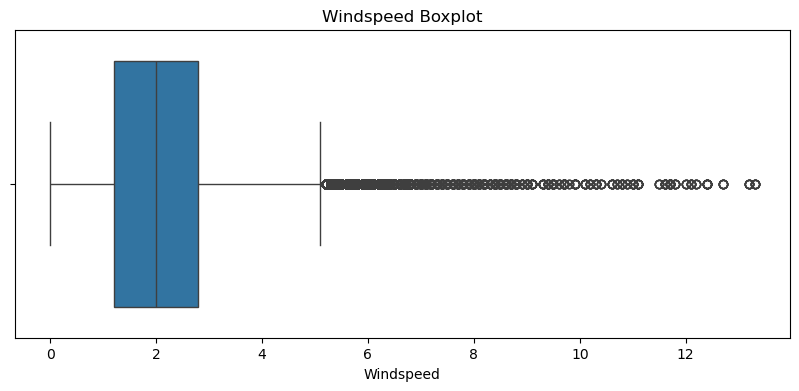

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=train_df['windspeed'])
plt.title('Windspeed Boxplot')
plt.xlabel('Windspeed')
plt.show()


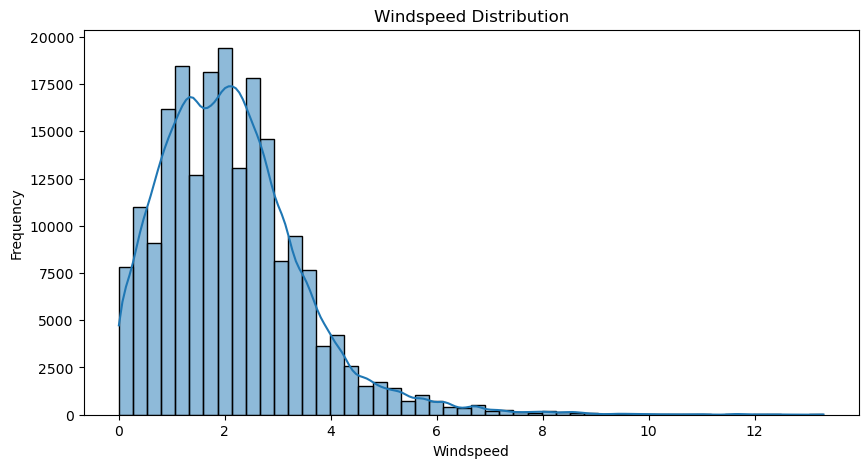

In [52]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['windspeed'], bins=50, kde=True)
plt.title('Windspeed Distribution')
plt.xlabel('Windspeed')
plt.ylabel('Frequency')
plt.show()


In [53]:
mean_windspeed = train_df['windspeed'].mean()
train_df['windspeed'] = train_df['windspeed'].fillna(mean_windspeed)

In [55]:
train_df['windspeed'].describe()

count    204000.000000
mean          2.134031
std           1.358045
min           0.000000
25%           1.200000
50%           2.000000
75%           2.800000
max          13.300000
Name: windspeed, dtype: float64

In [56]:
train_df['humidity'].describe()

count    203991.000000
mean         78.716295
std          15.080108
min          13.000000
25%          69.000000
50%          81.000000
75%          91.000000
max         100.000000
Name: humidity, dtype: float64

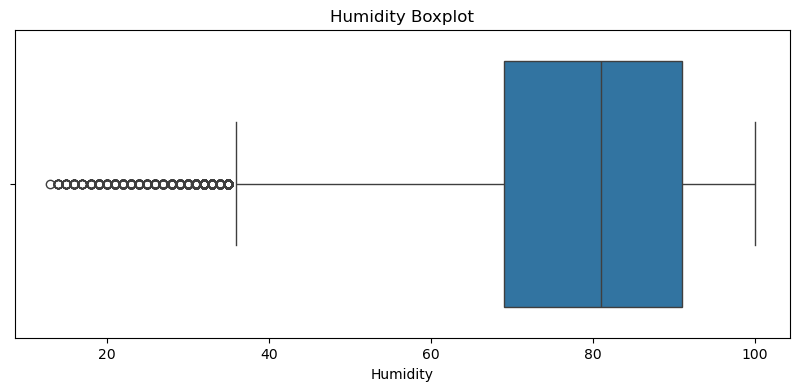

In [59]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=train_df['humidity'])
plt.title('Humidity Boxplot')
plt.xlabel('Humidity')
plt.show()

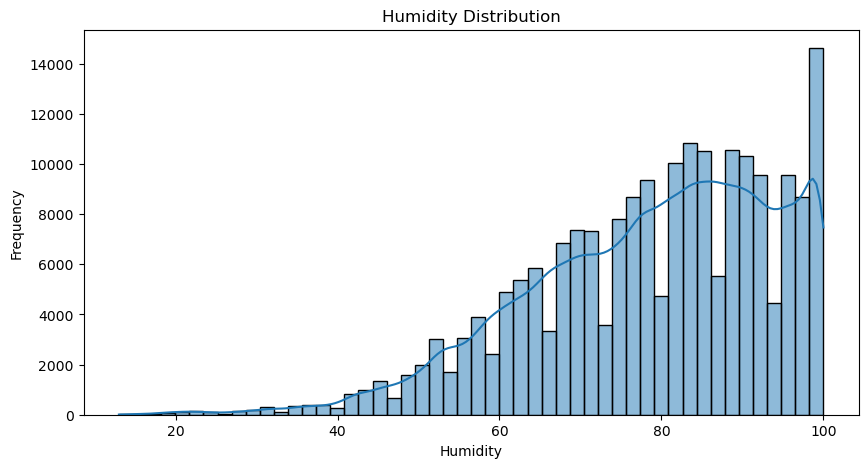

In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['humidity'], bins=50, kde=True)
plt.title('Humidity Distribution')
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.show()


In [61]:
mean_humidity = train_df['humidity'].mean()
train_df['humidity'] = train_df['humidity'].fillna(mean_humidity)

In [62]:
train_df['humidity'].describe()

count    204000.000000
mean         78.716295
std          15.079775
min          13.000000
25%          69.000000
50%          81.000000
75%          91.000000
max         100.000000
Name: humidity, dtype: float64

In [63]:
train_df.head(3)

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_device,ess_power_device,pcs_power_device
0,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28,Other Buildings,110634.0,39570.0,-,-,-,False,False,False
1,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36,Other Buildings,110634.0,39570.0,-,-,-,False,False,False
2,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88,Other Buildings,110634.0,39570.0,-,-,-,False,False,False


In [66]:
# 1. date_time을 datetime 형식으로 변환
train_df['date_time'] = pd.to_datetime(train_df['date_time'], format='%Y%m%d %H')

# 2. 연도, 월, 일, 요일, 시간 컬럼 분리
train_df['year'] = train_df['date_time'].dt.year
train_df['month'] = train_df['date_time'].dt.month
train_df['day'] = train_df['date_time'].dt.day
train_df['weekday'] = train_df['date_time'].dt.weekday
train_df['hour'] = train_df['date_time'].dt.hour

In [67]:
train_df.head(3)

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,...,ess_capacity,pcs_capacity,solar_power_device,ess_power_device,pcs_power_device,year,month,day,hour,weekday
0,1,2022-06-01 00:00:00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28,Other Buildings,...,-,-,False,False,False,2022,6,1,0,2
1,1,2022-06-01 01:00:00,18.0,NaN,1.1,45.0,NaN,NaN,1047.36,Other Buildings,...,-,-,False,False,False,2022,6,1,1,2
2,1,2022-06-01 02:00:00,17.7,NaN,1.5,45.0,NaN,NaN,974.88,Other Buildings,...,-,-,False,False,False,2022,6,1,2,2


In [70]:
test_df.head(3)

,building_number,date_time,temperature,rainfall,windspeed,humidity,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_device,ess_power_device,pcs_power_device,year,month,day,weekday,hour
0,1,2022-08-25 00:00:00,23.5,0.0,2.2,72,Other Buildings,110634.0,39570.0,-,-,-,False,False,False,2022,8,25,3,0
1,1,2022-08-25 01:00:00,23.0,0.0,0.9,72,Other Buildings,110634.0,39570.0,-,-,-,False,False,False,2022,8,25,3,1
2,1,2022-08-25 02:00:00,22.7,0.0,1.5,75,Other Buildings,110634.0,39570.0,-,-,-,False,False,False,2022,8,25,3,2


In [68]:
train_df.isna().sum()

building_number              0
date_time                    0
temperature                  0
rainfall                160069
windspeed                    0
humidity                     0
sunshine                 75182
solar_radiation          87913
power_consumption            0
building_type                0
total_area                   0
cooling_area                 0
solar_power_capacity         0
ess_capacity                 0
pcs_capacity                 0
solar_power_device           0
ess_power_device             0
pcs_power_device             0
year                         0
month                        0
day                          0
hour                         0
weekday                      0
dtype: int64

In [71]:
holiday_list = [
    '2022-01-01', '2022-01-31', '2022-02-01', '2022-02-02', '2022-03-01', '2022-03-09',
    '2022-05-05', '2022-05-08', '2022-06-01', '2022-06-06', '2022-08-15', '2022-09-09',
    '2022-09-10', '2022-09-11', '2022-09-12', '2022-10-03', '2022-10-09', '2022-10-10',
    '2022-12-25'
]

holiday_dates = pd.to_datetime(holiday_list)

In [ ]:
# 주말이면 holiday 컬럼에 True, 아니면 False로 설정
train_df['holiday'] = (train_df['date_time'].dt.weekday >= 5) | (train_df['date_time'].isin(holiday_dates))

In [73]:
train_df.head(3)

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,...,pcs_capacity,solar_power_device,ess_power_device,pcs_power_device,year,month,day,hour,weekday,holiday
0,1,2022-06-01 00:00:00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28,Other Buildings,...,-,False,False,False,2022,6,1,0,2,True
1,1,2022-06-01 01:00:00,18.0,NaN,1.1,45.0,NaN,NaN,1047.36,Other Buildings,...,-,False,False,False,2022,6,1,1,2,False
2,1,2022-06-01 02:00:00,17.7,NaN,1.5,45.0,NaN,NaN,974.88,Other Buildings,...,-,False,False,False,2022,6,1,2,2,False


In [75]:
train_df.columns

Index(['building_number', 'date_time', 'temperature', 'rainfall', 'windspeed',
       'humidity', 'sunshine', 'solar_radiation', 'power_consumption',
       'building_type', 'total_area', 'cooling_area', 'solar_power_capacity',
       'ess_capacity', 'pcs_capacity', 'solar_power_device',
       'ess_power_device', 'pcs_power_device', 'year', 'month', 'day', 'hour',
       'weekday', 'holiday'],
      dtype='object')

In [ ]:
def add_weather_indicators(train_df):
    # 불쾌지수 (Temperature-Humidity Index)
    train_df['THI'] = (
        (9 / 5) * train_df['temperature'] 
        - 0.55 * (1 - train_df['humidity'] / 100) * ((9 / 5) * train_df['temperature'] - 26) 
        + 32
    )

    # 체감온도 (Wind Chill)
    train_df['WC'] = (
        13.12 + 0.6215 * train_df['temperature'] 
        - 13.947 * (train_df['windspeed']**0.16) 
        + 0.486 * train_df['temperature'] * (train_df['windspeed']**0.16)
    )

    # CDH (Cumulative Degree Hours)
    def calculate_cdh(temps, window=12, threshold=26):
        # 초과 온도 계산 (음수는 0으로 처리)
        excess = np.maximum(temps - threshold, 0)
        # 누적합 슬라이딩 윈도우 방식
        cumsum = np.cumsum(np.insert(excess, 0, 0))
        return cumsum[window:] - cumsum[:-window]

    # 건물별로 CDH 계산
    cdhs = []
    for bnum in train_df['building_number'].unique():
        temp_data = train_df[train_df['building_number'] == bnum].copy()
        temps = temp_data['temperature'].values
        # 패딩 처리해서 원래 길이 유지
        cdh = calculate_cdh(temps)
        cdh_padded = np.concatenate([np.zeros(11), cdh])  # window-1 만큼 0 패딩
        cdhs.extend(cdh_padded)

    train_df['CDH'] = cdhs

    return train_df